 Llegó el momento de darle alma y personalidad a nuestro juego.

Esta clase se centra en el "feedback" para el jugador.  Vamos a añadir efectos de sonido y música.

### Clase 6:  Sprites y Sonido
#### Objetivo de la clase:
Aprender a cargar y mostrar imágenes (sprites) para nuestros objetos. Integrar efectos de sonido para eventos clave (tomar moneda, chocar con enemigo) y añadir música de fondo para crear atmósfera.

Duración: 2 horas.

### Recursos necesarios:
Antes de empezar, necesitarás algunas imágenes y sonidos.

### Imágenes en formato PNG (preferiblemente con fondo transparente):
player.png, coin.png, enemy.png.
Existen distintos lugares de descarga, por ejemplo:
https://craftpix.net/

https://laredgames.itch.io/gems-coins-free

https://itch.io/game-assets

https://www.gameart2d.com/freebies.html


Crear una carpeta llamada "assets" o "recursos" y guarda los assets ahí dentro para mantener el orden.

Ejemplo de descarga:
https://pixabay.com/sound-effects

https://www.bfxr.net/

Para mezcar sonidos.Música:
https://www.fesliyanstudios.com/royalty-free-music/downloads-c/8-bit-music/6

## Parte 1: De Rectángulos a Sprites
1. ¿Qué es un Sprite?
En los videojuegos 2D, un sprite es simplemente una imagen que representa a un personaje, un objeto o un efecto.

Hasta ahora, nuestro pygame.Rect ha cumplido dos funciones: definir la posición/tamaño y ser la forma visible.

### Ahora vamos a separarlas:

    self.image: Será la imagen visual del objeto.

    self.rect: Seguirá siendo la "caja de colisión" invisible que usamos para la lógica de movimiento y colisiones.

2. Cargando Imágenes en Pygame
El proceso es muy sencillo. Usaremos pygame.image.load(). Vamos a modificar nuestras clases para que carguen su propia imagen en el constructor.



          # ... (import pygame, random)

          # --- Modificamos la clase Player ---
          class Player:
              def __init__(self, x, y):
                  # Cargamos la imagen y obtenemos su rectángulo
                  self.image = pygame.image.load('assets/player.png').convert_alpha()
                  self.rect = self.image.get_rect()
                  # Posicionamos el rectángulo donde nos digan
                  self.rect.topleft = (x, y)
                  self.velocidad = 5

              def mover(self, teclas):
                  # ... (la lógica de movimiento es EXACTAMENTE la misma)
              
              def dibujar(self, superficie):
                  # En lugar de dibujar un rect, dibujamos la imagen en la posición del rect
                  superficie.blit(self.image, self.rect)

          # --- Modificamos la clase Enemy ---
          class Enemy:
              def __init__(self, x, y):
                  self.image = pygame.image.load('assets/enemy.png').convert_alpha()
                  self.rect = self.image.get_rect()
                  self.rect.topleft = (x, y)
                  self.velocidad_x = 3
                  # ... (el resto es igual)

              def update(self, ancho_pantalla, alto_pantalla):
                  # ... (la lógica de movimiento es EXACTAMENTE la misma)

              def dibujar(self, superficie):
                  superficie.blit(self.image, self.rect)



Explicación del Código:



*   pygame.image.load('ruta/a/la/imagen.png'): Carga el archivo de imagen y lo convierte en un objeto Surface de Pygame, que podemos manipular.
*   .convert_alpha(): Esta es una optimización crucial. Convierte la imagen a un formato interno de Pygame que hace que dibujarla en pantalla sea mucho más rápido. .convert() se usa para imágenes sin transparencia y .convert_alpha() para las que sí la tienen (como los PNG).
* self.rect = self.image.get_rect(): Crea automáticamente un Rect con las dimensiones exactas de la imagen que acabamos de cargar.
* superficie.blit(self.image, self.rect): blit ahora dibuja nuestra imagen en la pantalla, en la posición y con el tamaño definidos por self.rect.



3. Ajustando la Creación de Objetos
Como ahora el tamaño se define por la imagen, ya no necesitamos pasar el ancho y el alto al crear los objetos.


        # --- CREAMOS OBJETOS (versión actualizada) ---
        jugador = Player(50, 50) # Ya no necesita ancho y alto
        moneda = Collectible(300, 300)
        enemigo = Enemy(150, 150)

        # ... (el resto del código del bucle principal no cambia en absoluto)
        
  Prueba: Ejecuta el código.La lógica de colisiones y movimiento sigue funcionando perfectamente porque se basa en los Rect, que siguen existiendo "detrás" de las imágenes.


## Parte 2: Dando Voz al Juego - Sonidos y Música

1. Inicializando el Módulo de Sonido
Al igual que pygame.init(), necesitamos inicializar el módulo específico para el sonido. Esto se hace una sola vez, al principio del programa.


        import pygame
        # ...

        pygame.init()
        pygame.mixer.init() # Inicializamos el mezclador de sonido


2. Cargando Efectos de Sonido
Los efectos de sonido cortos (pasos, disparos, monedas) se cargan como objetos pygame.mixer.Sound. Los cargamos una sola vez, antes del bucle principal.
Se pueden descargar de
* https://freesound.org/search/?q=golpe
* https://www.bfxr.net/



        # ... (después de inicializar el mixer)

        # --- CARGAMOS SONIDOS ---
        sonido_moneda = pygame.mixer.Sound('assets/coin_sound.wav')
        sonido_golpe = pygame.mixer.Sound('assets/hit_sound.wav')

        # ... (resto del código)

3. Reproduciendo los Sonidos
Ahora, simplemente llamamos al método .play() de nuestro objeto de sonido en el momento exacto en que ocurre el evento.


          # ... (dentro del bucle principal, en la sección UPDATE)

          if estado_juego == 'jugando':
              # ... (update de movimiento)

              # Colisión con moneda
              if jugador.rect.colliderect(moneda.rect):
                  puntuacion += 1
                  sonido_moneda.play() # ¡Reproducimos el sonido!
                  # ... (mover moneda)

              # Colisión con enemigo
              if jugador.rect.colliderect(enemigo.rect):
                  sonido_golpe.play() # ¡Reproducimos el sonido!
                  estado_juego = 'game_over'


Prueba: ¡Ahora tu juego tiene feedback auditivo! Cada acción importante tiene una respuesta sonora, lo que enriquece la experiencia.

### Parte 3: Creando Atmósfera con Música de Fondo
1. La Diferencia entre Sound y Music
Pygame trata los efectos de sonido y la música de fondo de manera diferente:

* pygame.mixer.Sound: Para efectos cortos. Puedes tener muchos cargados y reproducir varios a la vez (por ejemplo, el sonido de un salto mientras suena una explosión).

* pygame.mixer.music: Para una única pista de música de fondo. Es un canal especial, optimizado para archivos más largos y streaming. Solo puedes tener una canción cargada y sonando a la vez.

La música se puede descargar de: https://opengameart.org/

2. Cargando y Reproduciendo Música
El proceso es similar, pero usa el módulo music.



        # --- ANTES DEL BUCLE PRINCIPAL ---

        # ... (cargamos los efectos de sonido)

        # --- CARGAMOS Y REPRODUCIMOS MÚSICA ---
        pygame.mixer.music.load('assets/background_music.ogg')
        pygame.mixer.music.play(-1) # El -1 significa que se repetirá en bucle infinito

        # ... (empieza el bucle principal)
### Explicación:

* pygame.mixer.music.load(): Carga el archivo de música.

* pygame.mixer.music.play(loops): Empieza a reproducir la música. El argumento loops indica cuántas veces se repetirá después de la primera vez.

* play(0): Suena una vez.

* play(2): Suena tres veces en total.

* play(-1): Suena para siempre.

Opcionalmente, puedes parar la música en la pantalla de "Game Over" para crear más impacto.



    # ... (dentro del if de colisión con el enemigo)
            if jugador.rect.colliderect(enemigo.rect):
                sonido_golpe.play()
                pygame.mixer.music.stop() # Paramos la música
                estado_juego = 'game_over'

    # ... (dentro del if de reinicio del juego)
                if evento.key == pygame.K_SPACE:
                    # ... (reiniciar variables)
                    pygame.mixer.music.play(-1) # Volvemos a poner la música
                    estado_juego = 'jugando'
                    
### Cierre y Próximos Pasos
Resumen de Hoy:  Nuestro motor ahora puede manejar sprites y un sistema de audio completo.

### Adelanto de la Clase 7:
"Hemos creado un juego de 'recolectar evitando'. Ahora, vamos a usar nuestro motor para construir un género clásico diferente: el Arkanoid. Esto introducirá nuevos desafíos: manejar una lista de objetos (los ladrillos), físicas más complejas (el rebote de una pelota) y un objetivo de juego diferente (limpiar la pantalla)."

### Tarea/Desafío:

Busca en internet (en sitios como opengameart.org o kenney.nl) diferentes sprites para el jugador, la moneda y el enemigo, y diferentes sonidos.

Intenta añadir un sonido que se reproduzca al reiniciar el juego en la pantalla de "Game Over".

Avanzado: Investiga pygame.mixer.music.set_volume(0.5) para bajar el volumen de la música si está muy alta.



## Clase extra - Accediendo a sprite individuales dentro de una spritesheet

Cuando usamos "spritesheets" o "hojas de sprites, significa que usamos una imagen grande que contiene muchos gráficos pequeños, esto se hace para el uso eficiente de la memoria y disco.

¿Cómo acceder a cada imagen individual con Pygame y qué herramientas te pueden ayudar?

### Spritesheets y cómo acceder a subimágenes en Pygame
Una spritesheet es una única imagen que contiene múltiples sprites más pequeños, a menudo organizados en una cuadrícula. Usar spritesheets es eficiente porque el juego solo tiene que cargar un archivo de imagen grande en memoria en lugar de muchos archivos pequeños.

Para acceder a una imagen específica dentro de una spritesheet en Pygame, usamos el método subsurface() de un objeto pygame.Surface.

## Cargar la spritesheet completa:

Primero, cargamos la imagen grande como lo harías normalmente:

      spritesheet = pygame.image.load('ruta/a/tu/spritesheet.png').convert_alpha()
      # Definir el Rectángulo de la Sub-imagen: Necesitamos saber la posición
      # (coordenadas x, y) y el tamaño (ancho, alto) del sprite individual que # queremos extraer dentro de la spritesheet. Esto se define con un pygame.#Rect.
      # Ejemplo: si cada sprite es de 32x32 píxeles y queremos que el sprite en #la primera fila, segunda columna (índice 1)

        sprite_width = 32
        sprite_height = 32
        sprite_column = 1 # Segunda columna (índice 1)
        sprite_row = 0    # Primera fila (índice 0)

        x = sprite_column * sprite_width
        y = sprite_row * sprite_height

        sprite_rect = pygame.Rect(x, y, sprite_width, sprite_height)


Extraer la Sub-imagen:
Usas el método subsurface() con el rectángulo que se definió:

    imagen_individual = spritesheet.subsurface(sprite_rect)


Ahora, imagen_individual es un objeto pygame.Surface que contiene solo el sprite que querías, y puedes usarlo como cualquier otra imagen cargada (por ejemplo, para self.image en tu clase GameObject).

¿Cómo Saber la Posición de Cada Sprite?
Aquí es donde entran las herramientas. Si tus sprites están organizados en una cuadrícula regular (todos del mismo tamaño y con el mismo espaciado), puedes calcular las coordenadas como en el ejemplo anterior.

Sin embargo, si los sprites tienen diferentes tamaños o están empaquetados de forma más eficiente para ahorrar espacio, calcular las posiciones manualmente es muy tedioso.

## Herramientas que Ayudan: Editores de Spritesheets


Existen herramientas diseñadas específicamente para crear y gestionar spritesheets. Te permiten importar sprites individuales y empaquetarlos en una sola hoja, o importar una spritesheet existente y definir los rectángulos de cada sprite. Lo más útil es que muchas de estas herramientas pueden exportar los datos de la posición y tamaño de cada sprite en un formato que tu juego pueda leer (como JSON o un archivo de texto simple).

## Algunas herramientas populares son:

TexturePacker: Una herramienta profesional muy potente (de pago, con versión de prueba). Optimiza el empaquetado de sprites para ahorrar espacio y puede exportar datos en muchos formatos compatibles con Pygame.
* https://www.codeandweb.com/texturepacker
* https://free-tex-packer.com/app/

ShoeBox: Una herramienta gratuita basada en Adobe Air (puede requerir una versión antigua de Air). Tiene una función de "Sprite Sheet" que te permite arrastrar imágenes y empaquetarlas, exportando los datos.
*https://renderhjs.net/shoebox/


LibreSprite / Piskel: Editores de pixel art que también tienen funciones básicas para trabajar con animaciones y exportar spritesheets.

Otras opciones:
https://ezgif.com/crop/ezgif-68f004536448d.png
https://www.piskelapp.com/
Tiles:
https://www.spritefusion.com/

## Flujo de Trabajo Típico con una Herramienta:

Diseñas o descargas tus sprites individuales.

*   Abres una herramienta como TexturePacker.
*   Arrastras tus archivos de imagen individuales a la herramienta.
*   La herramienta los empaqueta en una spritesheet grande.
*   Exportas la spritesheet Y un archivo de datos (ej: JSON) que contiene el nombre de cada sprite y su rectángulo (x, y, width, height) dentro de la hoja grande.
*   En tu juego Pygame, cargas la spritesheet y el archivo de datos.
*   Cuando necesites un sprite específico (ej: "player_idle"), buscas su rectángulo en los datos cargados y usas spritesheet.subsurface(rect) para extraerlo.
*   Usar una herramienta es la forma profesional de manejar spritesheets, especialmente para animaciones o juegos con muchos gráficos.





### Enlaces de interés:

https://www.piskelapp.com/

https://ezgif.com/
https://www.youtube.com/watch?v=lmL4BKXh7JI
https://www.youtube.com/watch?v=k__btrn473Y

ASEPRITE

https://www.youtube.com/watch?v=TPXzVd7b5Fg
https://libresprite.github.io/#!/


Ilustración para videojuegos

https://www.youtube.com/watch?v=g9eqGhus59Q
https://www.youtube.com/watch?v=zfJMdp97RAs

Pixel Art:

https://www.youtube.com/watch?v=G8jCc6igSGY
https://www.youtube.com/watch?v=WbwdFEPWR_U
https://www.youtube.com/watch?v=GnrLE_DhE6Y
https://www.youtube.com/watch?v=F8jdt9Rc1Mc
https://www.youtube.com/watch?v=UZYI13Y7v_4
https://www.youtube.com/watch?v=d-s-6GkBvGM
https://www.youtube.com/watch?v=Zg10c0zycVw
https://www.youtube.com/watch?v=CJA7-nx2lB0
https://www.youtube.com/watch?v=LKpoFVmXNnw
https://www.youtube.com/watch?v=KPl5bDowjXM
https://www.youtube.com/watch?v=Bm1gRlXWUT4
https://www.youtube.com/watch?v=tFsETEP01k8
https://opengameart.org/content/lpc-medieval-fantasy-character-sprites
https://www.youtube.com/watch?v=SM4xSs8ABdA

Sonidos

https://www.bfxr.net/

tilemap

https://www.youtube.com/watch?v=6gzVxLkz2-4
https://www.youtube.com/watch?v=UFjmoGevs7s

Piskel y json

https://www.youtube.com/watch?v=k__btrn473Y
https://github.com/LibreSprite/LibreSprite/releases/tag/v1.1

Pygame

https://www.youtube.com/watch?v=kVj8-O4MUlQ
https://www.youtube.com/watch?v=GR0zoMhpdiM
https://www.youtube.com/watch?v=ePiMYe7JpJo
https://www.youtube.com/watch?v=wDFKPnUbdB0
https://www.youtube.com/watch?v=4TfZjhw0J-8
https://www.youtube.com/watch?v=l_wRb2tL8rI
https://www.youtube.com/watch?v=Yn_Ss5yJr1E
https://www.youtube.com/watch?v=d-s-6GkBvGM
https://www.youtube.com/watch?v=EHt0YYp-O0g


## **Clase Extra: Animación de Personajes con Spritesheets en Pygame**



### **Objetivos de la clase**

  * Aprender a usar una herramienta de edición para marcar sprites de una `spritesheet`.
  * Comprender el formato de datos **JSON** para almacenar información de sprites y animaciones.
  * Implementar una clase `GameObject` que cargue la información de sprites desde un archivo JSON.
  * Actualizar una clase `Player` para que sus animaciones cambien según las acciones del jugador (ej. moverse o estar quieto).
  * Integrar las clases actualizadas en un bucle de juego funcional en Pygame.

-----

### **Parte 1: Creación de Spritesheets y JSON **

#### **Introducción al concepto de Spritesheet**

  * Explicación de qué es una `spritesheet` y por qué se usan en el desarrollo de videojuegos 🎮.
  * Breve discusión sobre cómo optimizan el rendimiento al reducir las llamadas al disco.

#### **Taller práctico con el editor de sprites**

1.  **Ejecutar la herramienta:** Se pide a los estudiantes que ejecuten el script de la aplicación de escritorio (https://github.com/apastorini/sprites_label/blob/main/editor.py).
      * `python editor.py`
2.  **Cargar la imagen:** Se les instruye a cargar una `spritesheet` (por ejemplo, una imagen con varios frames de un personaje caminando).
3.  **Marcar los sprites:** Los estudiantes usan el mouse para marcar cada sprite individualmente.
      * **Clic izquierdo:** Para dibujar un rectángulo alrededor de un sprite.
      * **Clic derecho:** Para guardar la selección y asignarle un nombre y una descripción.
4.  **Agrupar animaciones:** Se les enseña a usar el nuevo panel de animación para agrupar los sprites marcados.
      * Seleccionan los sprites que forman una animación (ej. todos los frames de `caminar`).
      * Escriben un nombre de animación (ej. `walk`) en el campo y presionan "Agrupar".
      * Repiten el proceso para otras animaciones (ej. `idle`).
5.  **Guardar el proyecto:** Guía para guardar el proyecto en un archivo JSON (ej. `player.json`). Se hace hincapié en la importancia de que el JSON y la imagen estén en la misma carpeta o que la ruta sea relativa.

-----

### **Parte 2: Implementación en Pygame **

#### **Actualización de las clases del juego**

  * **Revisión de `GameObject`:** Es el "cerebro" de la animación. Su principal cambio es el método **`load_from_json`**, que ahora parsea la nueva estructura de JSON para encontrar y organizar las animaciones.
  * **Revisión de `Player`:** Esta clase hereda de `GameObject`. Su constructor (`__init__`) ahora solo necesita la ruta al JSON. Se enfatiza cómo el método `mover` cambia dinámicamente la animación llamando a `super().update()`.
  * **Revisión de `Game`:** La clase principal del juego se modifica para crear el objeto `Player` usando la nueva lógica y para pasar el `dt` (delta time) en el bucle principal.

#### **Código completo**


```python
# game_object.py
import pygame
import random
import os
import json
import collections

# Colores y configuraciones del juego
ROJO = (255, 0, 0)
AZUL_OSCURO = (0, 0, 50)
BLANCO = (255, 255, 255)
NEGRO = (0, 0, 0)


class GameObject:
    def __init__(self, x, y, json_path):
        self.x = x
        self.y = y
        self.sprite_sheet = None
        self.animations = {}
        self.current_animation = 'idle'  # Animación por defecto
        self.frame_index = 0
        self.frame_timer = 0
        self.rect = None
        self.load_from_json(json_path)

    def load_from_json(self, json_path):
        try:
            absolute_json_path = os.path.abspath(json_path)
            with open(absolute_json_path, 'r') as f:
                data = json.load(f)

            spritesheet_path_relative = data.get('spritesheet_path')
            if not spritesheet_path_relative:
                raise ValueError("El JSON no tiene la clave 'spritesheet_path'.")
            
            spritesheet_path = os.path.normpath(os.path.join(os.path.dirname(absolute_json_path), spritesheet_path_relative))
            self.sprite_sheet = pygame.image.load(spritesheet_path).convert_alpha()
            
            self.animations = collections.defaultdict(list)
            for anim_name, anim_list in data.get('animations', {}).items():
                for sprite_data in anim_list:
                    self.animations[anim_name].append(
                        (sprite_data['x'], sprite_data['y'], sprite_data['width'], sprite_data['height'])
                    )
            
            if not self.animations:
                raise ValueError("No se encontraron animaciones válidas en el JSON.")

            self.current_animation = 'idle' if 'idle' in self.animations else list(self.animations.keys())[0]
            first_frame_rect_data = self.animations[self.current_animation][0]
            self.rect = pygame.Rect(self.x, self.y, first_frame_rect_data[2], first_frame_rect_data[3])

        except FileNotFoundError:
            print(f"Error: El archivo JSON o la spritesheet no fue encontrado en '{json_path}'.")
            self.sprite_sheet = None
            self.animations = {}
        except Exception as e:
            print(f"Error al cargar el JSON: {e}")
            self.sprite_sheet = None
            self.animations = {}

    def update(self, dt, action=None):
        if not self.animations: return
        if action and action in self.animations and self.current_animation != action:
            self.current_animation = action
            self.frame_index = 0
            self.frame_timer = 0
        
        frames = self.animations.get(self.current_animation, [])
        if not frames: return
            
        self.frame_timer += dt
        if self.frame_timer > 100:
            self.frame_index = (self.frame_index + 1) % len(frames)
            self.frame_timer = 0

    def draw(self, surface):
        if not self.sprite_sheet or not self.animations or not self.rect: return
            
        frame_rect_data = self.animations[self.current_animation][self.frame_index]
        frame = self.sprite_sheet.subsurface(pygame.Rect(frame_rect_data))
        surface.blit(frame, self.rect)


```


```python

class Player(GameObject):
    def __init__(self, x, y):
        json_path = os.path.join('assets', 'sprites', 'player_animation', 'player.json')
        super().__init__(x, y, json_path=json_path)
        self.velocidad = 5

    def mover(self, keys):
        moved = False
        if keys[pygame.K_LEFT]:
            self.x -= self.velocidad
            moved = True
        if keys[pygame.K_RIGHT]:
            self.x += self.velocidad
            moved = True

        if moved:
            self.update(0, 'walk')
        else:
            self.update(0, 'idle')

        self.rect.x = self.x
        self.rect.y = self.y

    def dibujar(self, superficie):
        self.draw(superficie)

```

```python
# enemy.py

import pygame
import os
from core.game_object import GameObject

class Enemy(GameObject):
    def __init__(self, x, y):
        """
        El constructor. Carga las animaciones del enemigo desde un archivo JSON.
        """
        # La ruta al JSON para el objeto enemigo
        json_path = os.path.join('assets', 'sprites', 'enemies', 'enemy.json')
        
        # Llamar al constructor de la clase padre.
        # No necesitamos pasarle el sprite_sheet ni las animaciones manualmente.
        super().__init__(x, y, json_path=json_path)

        # Damos al enemigo una velocidad en ambos ejes
        self.velocidad_x = 3
        self.velocidad_y = 3
        
        # El rect se creará automáticamente en el GameObject, solo necesitamos
        # ajustar su posición inicial.
        if self.rect:
            self.rect.topleft = (x, y)


    def update(self, dt, ancho_pantalla, alto_pantalla):
        """
        Actualiza la lógica del enemigo (movimiento y animación).
        """
        # Llamar a la función de la clase padre para actualizar la animación
        self.update(dt, 'walk')

        # Mover el enemigo
        self.rect.x += self.velocidad_x
        self.rect.y += self.velocidad_y

        # Lógica de rebote
        if self.rect.left <= 0 or self.rect.right >= ancho_pantalla:
            self.velocidad_x *= -1  # Invertir la dirección horizontal
        if self.rect.top <= 0 or self.rect.bottom >= alto_pantalla:
            self.velocidad_y *= -1  # Invertir la dirección vertical

    def dibujar(self, superficie):
        """
        Dibuja el enemigo en la pantalla.
        """
        self.draw(superficie)

```
```python
# collectible.py

import pygame
import os
from core.game_object import GameObject

class Collectible(GameObject):
    def __init__(self, x, y):
        """
        El constructor. Carga la apariencia desde un archivo JSON.
        """
        # La ruta al JSON para el objeto coleccionable
        json_path = os.path.join('assets', 'sprites', 'collectibles', 'coin.json')

        # Llamar al constructor de la clase padre
        super().__init__(x, y, json_path=json_path)

    def dibujar(self, superficie):
        """
        Dibuja el frame actual del sprite en la superficie.
        """
        self.draw(superficie)

```

```python

import pygame
import random
import os
import json
import collections

# Colores y configuraciones del juego
ROJO = (255, 0, 0)
AZUL_OSCURO = (0, 0, 50)
BLANCO = (255, 255, 255)
NEGRO = (0, 0, 0)



class Game:
    ANCHO = 800
    ALTO = 600
    PANTALLA = pygame.display.set_mode((ANCHO, ALTO))
    pygame.display.set_caption('Juego de Spritesheets')

    jugador = Player(50, 50)
    # Ejemplo de clase auxiliar para el Enemigo y Moneda
    # (Necesitas definirlas o importarlas para que esto funcione)
    # enemigo = Enemy(150, 150, (180, 50, 50))
    # moneda = Collectible(100, 100, (255, 223, 0))
    reloj = pygame.time.Clock()
    puntuacion = 0
    estado_juego = 'jugando'

    def __init__(self):
        # Reiniciar variables
        self.puntuacion = 0
        self.jugador.rect.topleft = (50, 50)
        # self.enemigo.rect.topleft = (random.randint(0, self.ANCHO - 40), 0)
        self.estado_juego = 'jugando'
        
        try:
            pygame.mixer.init()
            pygame.mixer.music.load('assets/music/song18.mp3')
            pygame.mixer.music.play(-1)
        except pygame.error as e:
            print(f"Error cargando música: {e}")

    def game_loop(self):
        ejecutando = True
        while ejecutando:
            dt = self.reloj.tick(60)
            
            # --- INPUT: Siempre procesar eventos, sin importar el estado del juego ---
            for evento in pygame.event.get():
                if evento.type == pygame.QUIT:
                    ejecutando = False
                
                # Manejo de la tecla de reinicio aquí, fuera del 'if' del estado de juego
                if self.estado_juego == 'game_over' and evento.type == pygame.KEYDOWN and evento.key == pygame.K_SPACE:
                    self.__init__()
            
            # --- Lógica del juego según el estado ---
            if self.estado_juego == 'jugando':
                teclas = pygame.key.get_pressed()
                self.jugador.mover(teclas)
                self.jugador.update(dt)

                # ... (resto de la lógica de colisiones y actualización)

            # --- Renderizado según el estado ---
            self.PANTALLA.fill(AZUL_OSCURO)

            if self.estado_juego == 'jugando':
                self.jugador.dibujar(self.PANTALLA)
                # ... (resto de renderizar)
            
            elif self.estado_juego == 'game_over':
                fuente_grande = pygame.font.Font(None, 72)
                fuente = pygame.font.Font(None, 36)
                texto_game_over = fuente_grande.render("GAME OVER", True, ROJO)
                texto_instruccion = fuente.render("Presiona ESPACIO para reiniciar", True, BLANCO)
                pos_game_over = texto_game_over.get_rect(center=(self.ANCHO / 2, self.ALTO / 2 - 50))
                pos_instruccion = texto_instruccion.get_rect(center=(self.ANCHO / 2, self.ALTO / 2 + 50))
                self.PANTALLA.blit(texto_game_over, pos_game_over)
                self.PANTALLA.blit(texto_instruccion, pos_instruccion)

            pygame.display.flip()

if __name__ == '__main__':
    game = Game()
    game.game_loop()
```

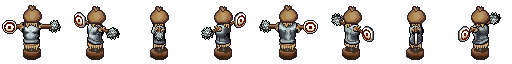